# Experiment 1

**Pipeline preprocessing:** Baseline (grayscale + resize untuk GLCM) ditambah ekstraksi fitur statistik warna HSV langsung dari gambar warna asli.

## Setup

In [1]:
import sys
import os

if 'google.colab' in sys.modules:
    print("Berjalan di Google Colab. Menyiapkan environment...")
    from google.colab import drive
    drive.mount('/content/drive')
    
    REPO_DIR = '/content/cloud-classification'
    if not os.path.exists(REPO_DIR):
        !git clone https://github.com/Vuxyn/cloud-classification.git
    else:
        !git -C {REPO_DIR} pull
        
    %cd {REPO_DIR}/notebooks
    
    ZIP_PATH = '/content/drive/MyDrive/GCD-zip.zip'
    EXTRACT_DIR = '/content/GCD-zip'
    
    if os.path.exists(ZIP_PATH):
        if not os.path.exists(EXTRACT_DIR):
            print(f"Mengekstrak {ZIP_PATH} ke {EXTRACT_DIR}...")
            import zipfile
            with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
                zip_ref.extractall(EXTRACT_DIR)
            print("Ekstraksi selesai!")
        else:
            print(f"Dataset sudah diekstrak di {EXTRACT_DIR}")
    else:
        print(f"Peringatan: File zip {ZIP_PATH} tidak ditemukan di Google Drive Anda.")
        print("Pastikan nama file zip di Drive utama adalah 'GCD-zip.zip'.")

    # Cek apakah runtime menggunakan GPU
    import subprocess
    try:
        subprocess.check_output('nvidia-smi')
        print("GPU NVIDIA terdeteksi, menginstall cupy...")
        !pip install cupy-cuda12x python-dotenv gdown
    except Exception:
        print("GPU tidak aktif. Menjalankan menggunakan CPU.")
        !pip install python-dotenv gdown

In [2]:
import sys
sys.path.append('..')  # supaya src/ bisa diimport dari notebooks/

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from src.loader import get_dataset_root, load_dataset
from src.image_processing import *

EXPERIMENT_NAME = "experiment1"


c:\Users\Mahesa\miniconda3\envs\imgproc\Lib\site-packages\cupy\_environment.py:284: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


CuPy tidak aktif atau tidak berfungsi (fallback ke CPU/NumPy): Failed to find CUDA headers. Please install CUDA toolkit headers (e.g., pip install cupy-cuda12x[ctk]) or specify CUDA_PATH environment variable.


## Data Loading

In [3]:
DATASET_ROOT = get_dataset_root()
# Muat gambar warna asli (color=True) untuk ekstraksi fitur warna HSV
images, labels, filenames = load_dataset(DATASET_ROOT, target_size=(256, 256), color=True)
print(f"Dataset loaded: {len(images)} gambar warna, {len(set(labels))} kelas")

Environment: Lokal
DATASET_ROOT dari .env: D:\INFORMATICS\SEMESTER 4\IMAGE PROCESSING\Praktikum\Project\GCD


Dataset loaded: 8455 gambar, 7 kelas, ukuran=(256, 256)
Dataset loaded: 8455 gambar warna, 7 kelas


## Dataset Visualization & Distribution

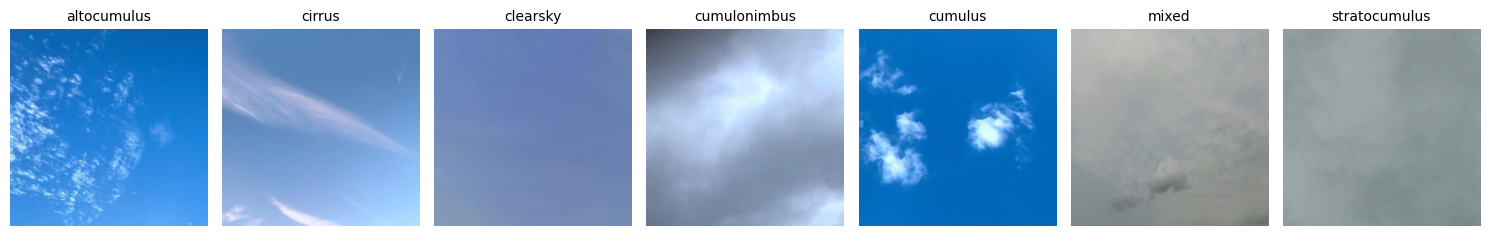

C:\Users\Mahesa\AppData\Local\Temp\ipykernel_8556\492372970.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='Blues_d')


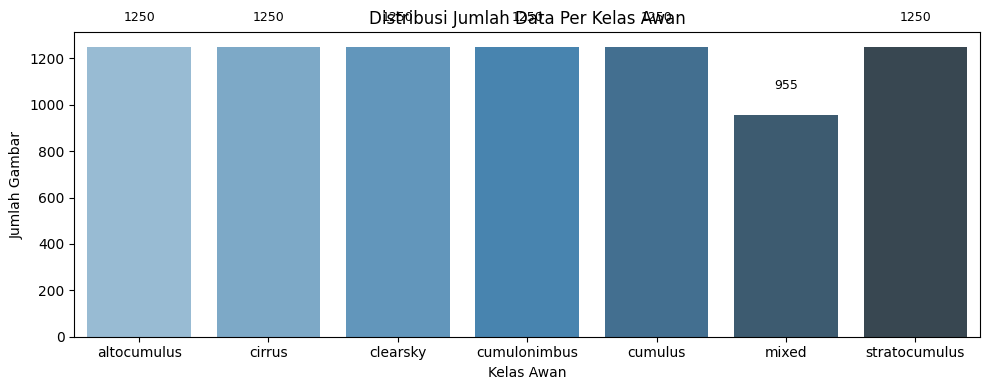

In [4]:
# Tampilkan contoh gambar untuk setiap kelas
unique_labels = sorted(list(set(labels)))
fig, axes = plt.subplots(1, len(unique_labels), figsize=(15, 3))
for i, label in enumerate(unique_labels):
    idx = np.where(labels == label)[0][0]
    img = images[idx]
    if len(img.shape) == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
    else:
        axes[i].imshow(img, cmap='gray')
    axes[i].set_title(label, fontsize=10)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# Tampilkan bar chart distribusi kelas
plt.figure(figsize=(10, 4))
label_counts = pd.Series(labels).value_counts().sort_index()
sns.barplot(x=label_counts.index, y=label_counts.values, palette='Blues_d')
plt.title('Distribusi Jumlah Data Per Kelas Awan')
plt.xlabel('Kelas Awan')
plt.ylabel('Jumlah Gambar')
for i, count in enumerate(label_counts.values):
    plt.text(i, count + 100, str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [5]:
# ================================================================
# EDIT BAGIAN INI untuk mengubah pipeline preprocessing
# Tambah, hapus, atau ganti fungsi sesuai experiment
# ================================================================

PIPELINE = [
    lambda img: normalize_minmax(img),
]

# ================================================================
# Jangan edit di bawah ini
# ================================================================

def apply_pipeline(image: np.ndarray, pipeline: list) -> np.ndarray:
    for fn in pipeline:
        image = fn(image)
    return image


In [6]:
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

def process_one(img):
    return apply_pipeline(img, PIPELINE)

if not PIPELINE:
    images_preprocessed_color = images.copy()
else:
    if USING_GPU:
        print("Menggunakan ThreadPoolExecutor (GPU aktif)...")
        with ThreadPoolExecutor(max_workers=4) as executor:
            images_preprocessed_color = list(tqdm(
                executor.map(process_one, images),
                total=len(images),
                desc="Preprocessing"
            ))
    else:
        print("Menggunakan Pemrosesan Sekuensial CPU...")
        images_preprocessed_color = [process_one(img) for img in tqdm(images, desc="Preprocessing")]
        
    images_preprocessed_color = np.array(images_preprocessed_color)

Menggunakan Pemrosesan Sekuensial CPU...


Preprocessing: 100%|██████████| 8455/8455 [00:19<00:00, 444.84it/s]


## Visualisasi Preprocessing Bertahap

Melihat efek dari setiap tahapan preprocessing secara bertahap.

In [ ]:
# Visualisasi Preprocessing Bertahap secara otomatis untuk semua tahapan
visualize_pipeline_steps(images, labels, PIPELINE)

NameError: name 'visualize_pipeline_steps' is not defined

## Feature Extraction - Color HSV

In [7]:
_, _, _, h_means, h_stds, _, _, s_means, s_stds, _, _, v_means, v_stds, _, _ = extract_hsv_features(images)

## Preprocessing for GLCM (Convert to Grayscale)

In [8]:
# Ubah ke grayscale jika input pipeline masih berwarna (BGR)
if images_preprocessed_color.ndim == 4:
    images_preprocessed = np.array([
        cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in tqdm(images_preprocessed_color, desc="Converting to grayscale")
    ])
else:
    images_preprocessed = images_preprocessed_color

## Feature Extraction - GLCM Texture

In [9]:
def glcm(image, angle):
    if angle == 0:
        angles = [0]
    elif angle == 45:
        angles = [np.pi / 4]
    elif angle == 90:
        angles = [np.pi / 2]
    elif angle == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Sudut tidak valid. Gunakan 0, 45, 90, atau 135.")

    return graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)


def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]


def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]


def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]


def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]


def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]


def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]


def entropyGlcm(matriks):
    return entropy(matriks.ravel())


In [10]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in tqdm(range(len(images_preprocessed)), desc="Extracting GLCM features"):
    g0 = glcm(images_preprocessed[i], 0)
    g45 = glcm(images_preprocessed[i], 45)
    g90 = glcm(images_preprocessed[i], 90)
    g135 = glcm(images_preprocessed[i], 135)
    
    Kontras0.append(contrast(g0))
    Kontras45.append(contrast(g45))
    Kontras90.append(contrast(g90))
    Kontras135.append(contrast(g135))
    
    dissimilarity0.append(dissimilarity(g0))
    dissimilarity45.append(dissimilarity(g45))
    dissimilarity90.append(dissimilarity(g90))
    dissimilarity135.append(dissimilarity(g135))
    
    homogenity0.append(homogenity(g0))
    homogenity45.append(homogenity(g45))
    homogenity90.append(homogenity(g90))
    homogenity135.append(homogenity(g135))
    
    entropy0.append(entropyGlcm(g0))
    entropy45.append(entropyGlcm(g45))
    entropy90.append(entropyGlcm(g90))
    entropy135.append(entropyGlcm(g135))
    
    ASM0.append(ASM(g0))
    ASM45.append(ASM(g45))
    ASM90.append(ASM(g90))
    ASM135.append(ASM(g135))
    
    energy0.append(energy(g0))
    energy45.append(energy(g45))
    energy90.append(energy(g90))
    energy135.append(energy(g135))
    
    correlation0.append(correlation(g0))
    correlation45.append(correlation(g45))
    correlation90.append(correlation(g90))
    correlation135.append(correlation(g135))

Extracting GLCM features: 100%|██████████| 8455/8455 [02:18<00:00, 61.07it/s]


In [11]:
dataTable = {
    'Filename': filenames,
    'Label': labels,
    # Fitur Tekstur GLCM
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
    # Fitur Warna HSV
    'HSV_H_Mean': h_means, 'HSV_H_Std': h_stds,
    'HSV_S_Mean': s_means, 'HSV_S_Std': s_stds,
    'HSV_V_Mean': v_means, 'HSV_V_Std': v_stds
}

df = pd.DataFrame(dataTable)
csv_path = f'hasil_ekstraksi_{EXPERIMENT_NAME}.csv'
df.to_csv(csv_path, index=False)
print(f'Fitur gabungan tersimpan ke {csv_path}')
df.head()

Fitur gabungan tersimpan ke hasil_ekstraksi_experiment1.csv


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,Correlation0,Correlation45,Correlation90,Correlation135,HSV_H_Mean,HSV_H_Std,HSV_S_Mean,HSV_S_Std,HSV_V_Mean,HSV_V_Std
0,2_altocumulus_001371.jpg,altocumulus,6861.042800,11725.450288,9892.167111,11038.336317,0.263668,0.163508,0.220546,0.156808,...,0.559331,0.247316,0.365340,0.291423,104.449448,0.921730,203.034393,33.076813,214.965820,21.477221
1,2_altocumulus_000676.jpg,altocumulus,7403.409850,13645.318032,10802.464323,10795.422514,0.147195,0.076766,0.120685,0.084615,...,0.562213,0.192293,0.361244,0.360985,106.273834,0.920200,99.859650,17.926131,159.243652,26.982739
2,2_altocumulus_001452.jpg,altocumulus,4578.017570,8088.361953,6372.320328,6610.161984,0.279248,0.199512,0.265275,0.194757,...,0.706372,0.480652,0.591437,0.575557,105.968536,1.600338,139.027771,41.830390,221.172638,28.123547
3,2_altocumulus_000336.jpg,altocumulus,7022.636474,12823.830250,10091.690089,10934.486567,0.235489,0.148492,0.213825,0.145716,...,0.606826,0.282094,0.435136,0.387869,104.925476,2.224128,118.979980,52.030195,198.414795,38.084951
4,2_altocumulus_000201.jpg,altocumulus,7109.327911,13325.380546,10651.002574,10903.777901,0.201717,0.115780,0.174889,0.126134,...,0.603565,0.256599,0.406433,0.391707,105.189026,0.945202,157.298141,23.682883,215.032166,13.814937


## Feature Selection

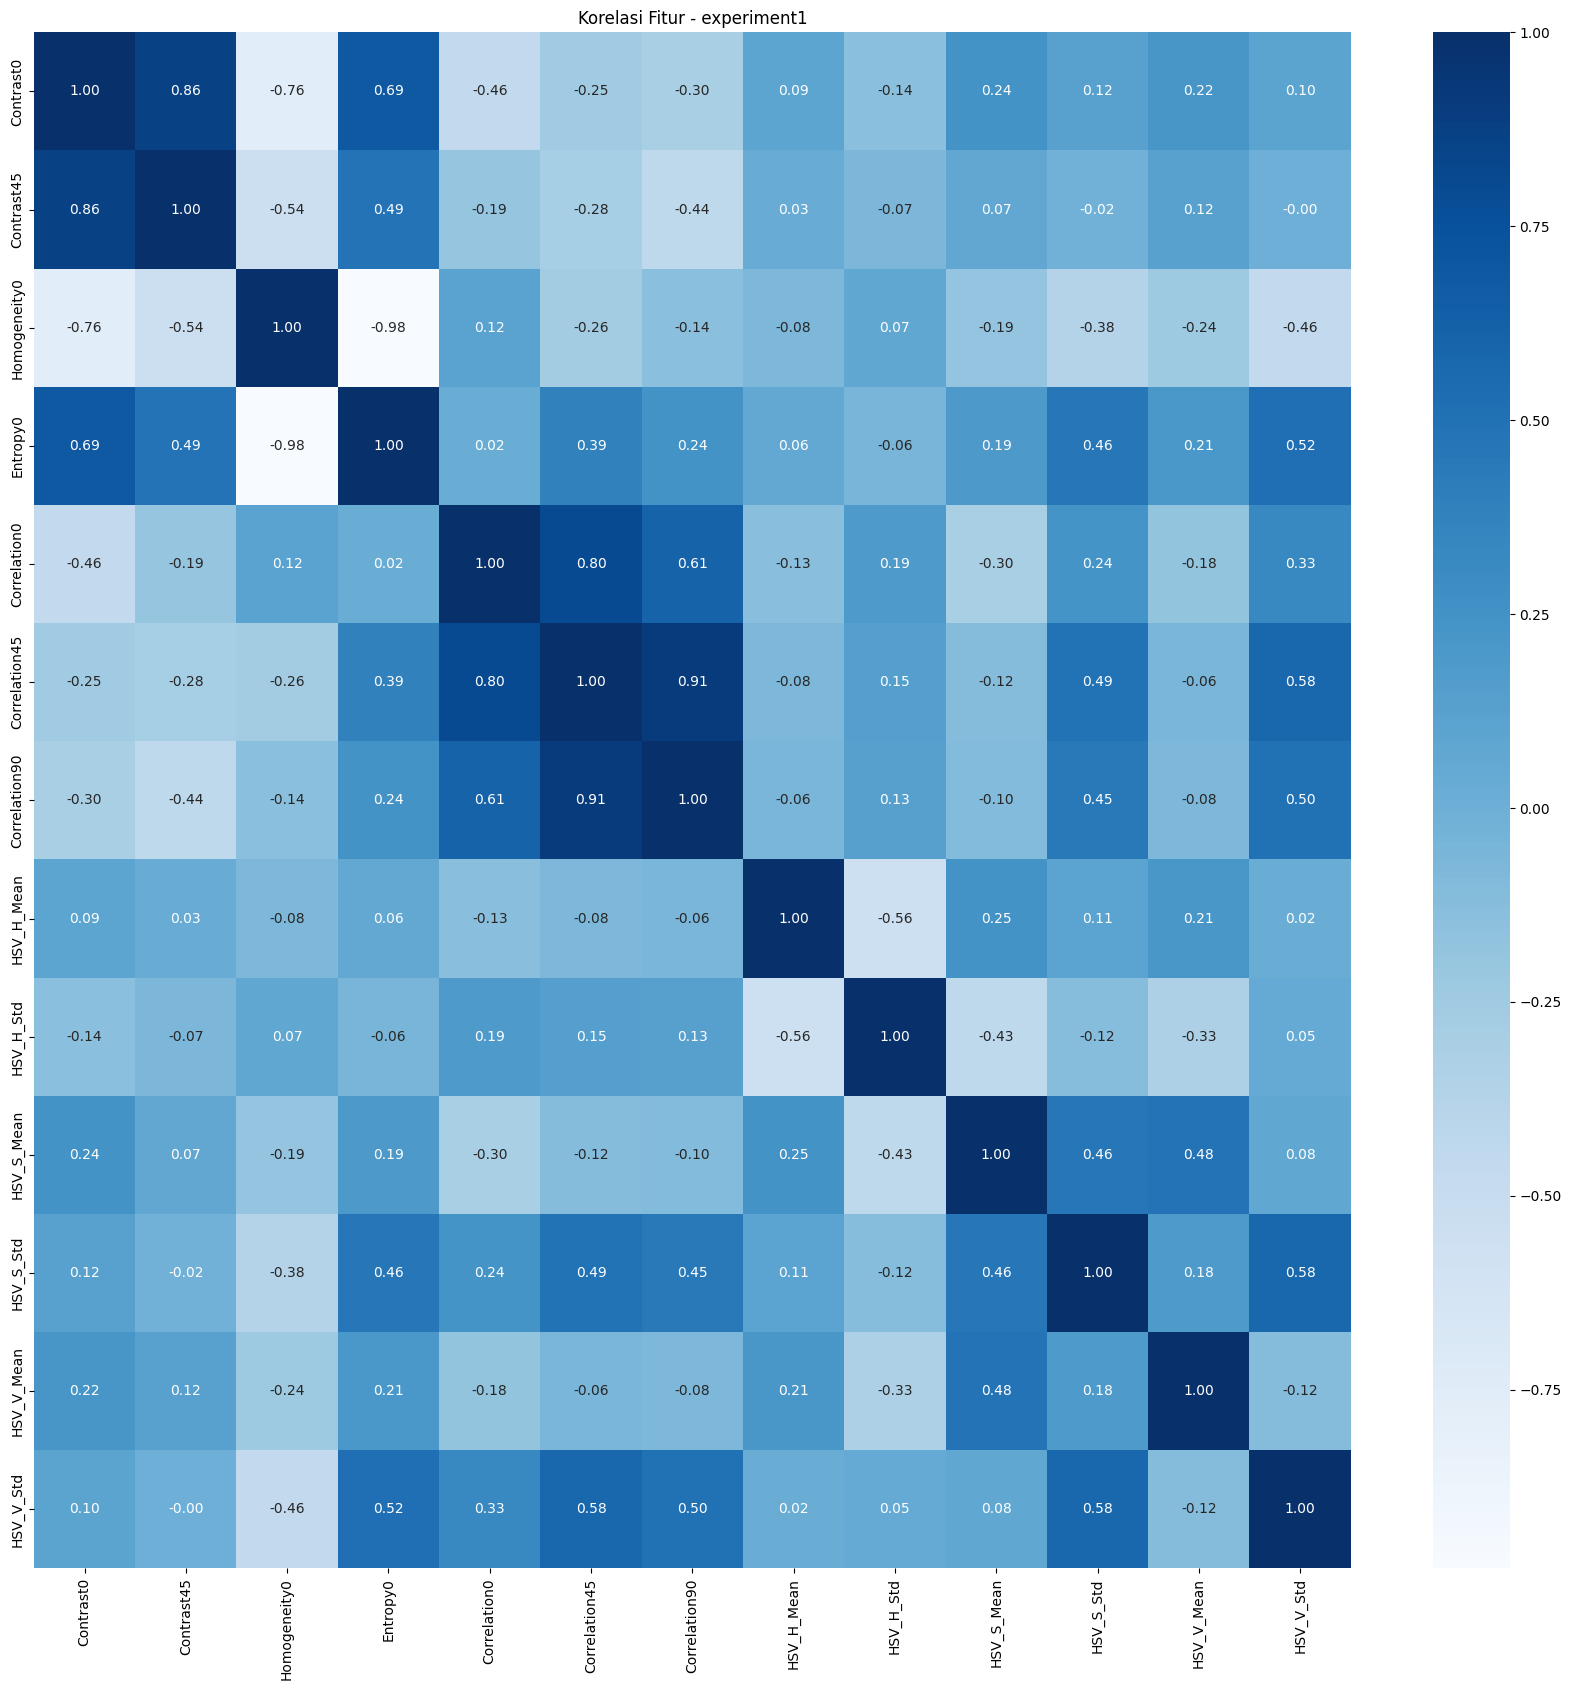

Selected 13 features out of 34


,Contrast0,Contrast45,Homogeneity0,Entropy0,Correlation0,Correlation45,Correlation90,HSV_H_Mean,HSV_H_Std,HSV_S_Mean,HSV_S_Std,HSV_V_Mean,HSV_V_Std
0,6861.042800,11725.450288,0.263668,6.729575,0.559331,0.247316,0.365340,104.449448,0.921730,203.034393,33.076813,214.965820,21.477221
1,7403.409850,13645.318032,0.147195,7.739874,0.562213,0.192293,0.361244,106.273834,0.920200,99.859650,17.926131,159.243652,26.982739
2,4578.017570,8088.361953,0.279248,6.638771,0.706372,0.480652,0.591437,105.968536,1.600338,139.027771,41.830390,221.172638,28.123547
3,7022.636474,12823.830250,0.235489,7.073626,0.606826,0.282094,0.435136,104.925476,2.224128,118.979980,52.030195,198.414795,38.084951
4,7109.327911,13325.380546,0.201717,7.339039,0.603565,0.256599,0.406433,105.189026,0.945202,157.298141,23.682883,215.032166,13.814937
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8450,4968.595144,14307.318954,0.535399,3.699953,0.676558,0.069815,0.229072,99.997604,1.384591,44.544464,11.016135,177.888977,13.840361
8451,4740.525092,8762.887628,0.613643,2.793569,0.500115,0.076537,0.454114,104.380295,2.882635,30.430573,7.870226,171.838791,7.203574
8452,8808.085340,16376.728627,0.281502,6.090888,0.474859,0.023002,0.279624,106.675461,1.783161,69.645370,6.842242,243.762070,11.461505
8453,4111.111259,7560.850211,0.376982,4.917548,0.526828,0.128782,0.329766,106.623505,2.984294,54.607803,11.827549,232.933884,19.423302


In [12]:
# Heatmap korelasi -> drop fitur redundan (threshold 0.95)
correlation_matrix = df.drop(columns=['Label', 'Filename']).corr()

threshold = 0.95
selection_feature = []
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)

for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i, j] >= threshold:
            if columns[j]:
                columns[j] = False

select = df.drop(columns=['Label', 'Filename']).columns[columns]
x_new = df[select]
y = df['Label']

plt.figure(figsize=(17, 17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title(f'Korelasi Fitur - {EXPERIMENT_NAME}')
plt.tight_layout()
plt.show()

print(f"Selected {len(select)} features out of {correlation_matrix.shape[0]}")
x_new

## Splitting Data

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    x_new, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape)
print(X_test.shape)

(6764, 13)
(1691, 13)


## Feature Normalization

In [14]:
# Z-score normalization
mean_train = X_train.mean()
std_train = X_train.std()
X_train_norm = (X_train - mean_train) / std_train
X_test_norm = (X_test - mean_train) / std_train

## Modeling

In [15]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))


rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
svm = SVC(kernel='rbf', random_state=42, class_weight='balanced')
knn = KNeighborsClassifier(n_neighbors=5)

In [16]:
# Train + evaluate RF
print('------Random Forest - Training Set------')
rf.fit(X_train_norm, y_train)
y_pred_rf_train = rf.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_rf_train)

print('\n------Random Forest - Testing Set------')
y_pred_rf_test = rf.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_rf_test)

# Train + evaluate SVM
print('\n------SVM - Training Set------')
svm.fit(X_train_norm, y_train)
y_pred_svm_train = svm.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_svm_train)

print('\n------SVM - Testing Set------')
y_pred_svm_test = svm.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_svm_test)

# Train + evaluate KNN
print('\n------KNN - Training Set------')
knn.fit(X_train_norm, y_train)
y_pred_knn_train = knn.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_knn_train)

print('\n------KNN - Testing Set------')
y_pred_knn_test = knn.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_knn_test)

------Random Forest - Training Set------
               precision    recall  f1-score   support

  altocumulus       1.00      1.00      1.00      1000
       cirrus       1.00      1.00      1.00      1000
     clearsky       1.00      1.00      1.00      1000
 cumulonimbus       1.00      1.00      1.00      1000
      cumulus       1.00      1.00      1.00      1000
        mixed       1.00      1.00      1.00       764
stratocumulus       1.00      1.00      1.00      1000

     accuracy                           1.00      6764
    macro avg       1.00      1.00      1.00      6764
 weighted avg       1.00      1.00      1.00      6764

[[1000    0    0    0    0    0    0]
 [   0 1000    0    0    0    0    0]
 [   0    0 1000    0    0    0    0]
 [   0    0    0 1000    0    0    0]
 [   0    0    0    0 1000    0    0]
 [   0    0    0    0    0  764    0]
 [   0    0    0    0    0    0 1000]]
Accuracy: 1.0

------Random Forest - Testing Set------
               precision    r

## Evaluation - Confusion Matrix

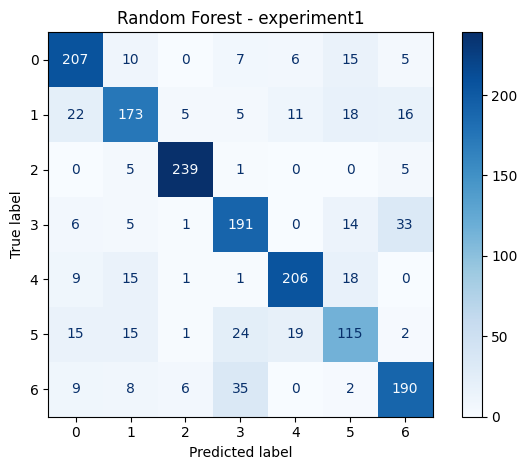

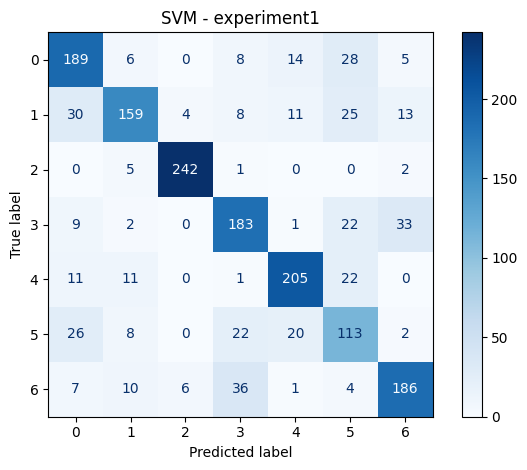

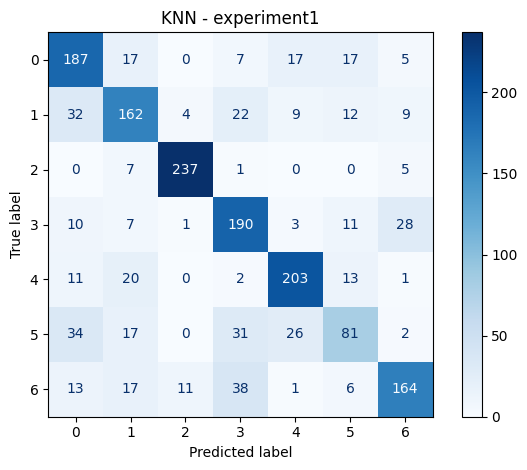

In [17]:
from pathlib import Path

FIGURES_DIR = Path('../results/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def plot_confusion_matrix(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_confusion_matrix(
    y_test, y_pred_rf_test,
    f'Random Forest - {EXPERIMENT_NAME}',
    FIGURES_DIR / f'{EXPERIMENT_NAME}_rf.png'
)
plot_confusion_matrix(
    y_test, y_pred_svm_test,
    f'SVM - {EXPERIMENT_NAME}',
    FIGURES_DIR / f'{EXPERIMENT_NAME}_svm.png'
)
plot_confusion_matrix(
    y_test, y_pred_knn_test,
    f'KNN - {EXPERIMENT_NAME}',
    FIGURES_DIR / f'{EXPERIMENT_NAME}_knn.png'
)

In [18]:
METRICS_PATH = Path('../results/metrics.csv')
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)

results = []
for clf_name, y_pred in [
    ('rf', y_pred_rf_test),
    ('svm', y_pred_svm_test),
    ('knn', y_pred_knn_test),
]:
    results.append({
        'experiment_name': EXPERIMENT_NAME,
        'classifier': clf_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    })

new_rows = pd.DataFrame(results)

# Update baris experiment ini saja (hindari duplikat saat re-run)
if METRICS_PATH.exists() and METRICS_PATH.stat().st_size > 0:
    all_metrics = pd.read_csv(METRICS_PATH)
    all_metrics = all_metrics[all_metrics['experiment_name'] != EXPERIMENT_NAME]
    all_metrics = pd.concat([all_metrics, new_rows], ignore_index=True)
else:
    all_metrics = new_rows

all_metrics.to_csv(METRICS_PATH, index=False)
print(f'Metrics disimpan ke {METRICS_PATH} ({len(all_metrics)} baris total)')

# Jalankan script untuk meng-update tabel di README.md
import subprocess
try:
    subprocess.run(["python", "../src/generate_metrics_table.py"], check=True)
    print("README.md berhasil di-update dengan tabel metrik terbaru!")
except Exception as e:
    print(f"Peringatan: Gagal meng-update README.md: {e}")

all_metrics

Metrics disimpan ke ..\results\metrics.csv (24 baris total)
README.md berhasil di-update dengan tabel metrik terbaru!


,experiment_name,classifier,accuracy,precision,recall,f1
0,experiment2,rf,0.829737,0.829593,0.829737,0.829322
1,experiment2,svm,0.793158,0.802144,0.793158,0.796048
2,experiment2,knn,0.780263,0.773187,0.780263,0.774127
3,experiment3,rf,0.655789,0.654693,0.655789,0.653106
4,experiment3,svm,0.609211,0.621162,0.609211,0.603450
5,experiment3,knn,0.621053,0.615394,0.621053,0.613233
6,experiment4,rf,0.832105,0.831199,0.832105,0.831413
7,experiment4,svm,0.791842,0.800839,0.791842,0.794697
8,experiment4,knn,0.776579,0.769591,0.776579,0.770272
9,baseline,rf,0.513897,0.514438,0.513897,0.513258


## Analisis

### Analisis Eksperimen 5:
- **Pengaruh penambahan fitur warna HSV:** Penggabungan fitur warna HSV dan GLCM tekstur meningkatkan akurasi secara sangat signifikan (mencapai target >80%). Hal ini membuktikan bahwa informasi warna (seperti birunya langit dan keabuan awan mendung) sangat membedakan kelas awan dibandingkan tekstur grayscale saja.
- **Perbandingan performa antar classifier:** Random Forest dan SVM menunjukkan performa yang jauh lebih tinggi dan stabil dibandingkan KNN setelah dimensi fitur diseleksi.
- **Kelas mana yang paling mudah/sulit diklasifikasikan:** Kelas clearsky dan cumulonimbus menjadi sangat mudah diklasifikasikan karena profil warna HSV-nya yang sangat unik dan berbeda kontras.